# PySlice Neural Network Loss Landscape Analysis

This notebook demonstrates how to use PySlice to analyze the loss landscapes of real neural networks. We'll train a simple CNN on MNIST and explore how the loss landscape relates to model performance and generalization.

Key insights we'll explore:
- **2D Random Direction Slicing**: Shows how loss surface roughness correlates with generalization
- **Axis-Parallel Slicing**: Reveals which parameters have the most influence on loss
- **Training Evolution**: How the landscape changes during training
- **Generalization Analysis**: Comparing well-trained vs. poorly-trained models

In [25]:
# Standard libraries
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# PySlice library components
from pysclice.slicers import LinearInterpolationSlicer, AxisParallelSlicer, RandomDirectionSlicer
from pysclice.core import ModelWrapper
from pysclice.visualization import plot_slices

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [26]:
# Hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 0.01
EPOCHS = 5

# Slicing parameters
SLICING_STEPS = 30
PARAM_RANGE = 3
FOCUS_POINTS = 20

## 1. Dataset and Model Setup

We'll use a very simple neural network with only ~16 parameters on MNIST for binary classification (digits 0-4 vs 5-9). This tiny network is perfect for demonstrating axis-parallel slicing where we can visualize the effect of each individual parameter.

The network uses only the center 2x2 pixels of each 28x28 image and has the architecture:
- Input: 4 features (center 2x2 pixels)
- Hidden layer: 2 neurons  
- Output: 2 classes (binary classification)

This gives us exactly 16 parameters total, making axis-parallel visualization meaningful and interpretable.

In [27]:
# Data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


In [28]:
# Very simple neural network with only ~16 parameters
class TinyNN(nn.Module):
    def __init__(self):
        super(TinyNN, self).__init__()
        # Final approach: 4 -> 2 -> 2 (binary classification for simplicity)
        self.fc1 = nn.Linear(4, 2)   # 4*2 + 2 = 10 parameters
        self.fc2 = nn.Linear(2, 2)   # 2*2 + 2 = 6 parameters
        # Total: 16 parameters - perfect for visualization!
        
    def forward(self, x):
        # Take only center 2x2 pixels from 28x28 image
        batch_size = x.size(0)
        center_pixels = x[:, :, 13:15, 13:15]  # Center 2x2
        # Ensure contiguous memory layout and reshape to 4 features
        x = center_pixels.contiguous().reshape(batch_size, -1)
        
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Create model
model = TinyNN().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# Print parameter breakdown
for name, param in model.named_parameters():
    print(f"{name}: {param.numel()} parameters, shape: {param.shape}")

Model parameters: 16
fc1.weight: 8 parameters, shape: torch.Size([2, 4])
fc1.bias: 2 parameters, shape: torch.Size([2])
fc2.weight: 4 parameters, shape: torch.Size([2, 2])
fc2.bias: 2 parameters, shape: torch.Size([2])


## 2. Training with Loss Landscape Snapshots

We'll train the model while capturing snapshots at different stages to see how the loss landscape evolves.

In [29]:
# Training function for binary classification
def train_model(model, train_loader, test_loader, epochs=5, lr=0.01):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.NLLLoss()
    
    model_snapshots = []
    train_losses = []
    test_accuracies = []
    
    # Save initial state
    model_snapshots.append(copy.deepcopy(model.state_dict()))
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Convert to binary classification (0-4 -> 0, 5-9 -> 1)
            binary_target = (target >= 5).long()
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, binary_target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # Testing
        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                binary_target = (target >= 5).long()
                
                output = model(data)
                test_loss += criterion(output, binary_target).item()
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(binary_target.view_as(pred)).sum().item()
        
        train_loss /= len(train_loader)
        test_accuracy = 100. * correct / len(test_loader.dataset)
        
        train_losses.append(train_loss)
        test_accuracies.append(test_accuracy)
        
        # Save model state
        model_snapshots.append(copy.deepcopy(model.state_dict()))
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
    
    return model_snapshots, train_losses, test_accuracies

# Train the model
model_snapshots, train_losses, test_accuracies = train_model(model, train_loader, test_loader, EPOCHS, LEARNING_RATE)

Epoch 1: Train Loss: 0.6889, Test Accuracy: 54.87%
Epoch 2: Train Loss: 0.6760, Test Accuracy: 57.61%
Epoch 3: Train Loss: 0.6729, Test Accuracy: 57.60%
Epoch 4: Train Loss: 0.6711, Test Accuracy: 57.35%
Epoch 5: Train Loss: 0.6698, Test Accuracy: 57.76%


## 3. Prepare Models for PySlice Analysis

We'll create PySlice-compatible model wrappers for our trained models.

In [30]:
# Create a subset of data for faster loss landscape computation
def create_data_subset(loader, n_samples=1000):
    data_list = []
    target_list = []
    count = 0
    
    for data, target in loader:
        data_list.append(data)
        target_list.append(target)
        count += data.size(0)
        if count >= n_samples:
            break
    
    return torch.cat(data_list)[:n_samples], torch.cat(target_list)[:n_samples]

# Create data subsets
train_data_subset = create_data_subset(train_loader, 1000)
test_data_subset = create_data_subset(test_loader, 1000)

print(f"Train subset: {train_data_subset[0].shape}")
print(f"Test subset: {test_data_subset[0].shape}")

Train subset: torch.Size([1000, 1, 28, 28])
Test subset: torch.Size([1000, 1, 28, 28])


In [31]:
# Create ModelWrapper for PySlice
def create_model_wrapper(model_state, train_data, test_data):
    # Create a new model instance
    model_copy = TinyNN().to(device)
    model_copy.load_state_dict(model_state)
    
    # Loss function that matches ModelWrapper's expected signature
    def loss_fn(outputs, targets):
        # Convert targets to binary classification
        binary_targets = (targets >= 5).long()
        return F.nll_loss(outputs, binary_targets.to(device))
    
    return ModelWrapper(
        model=model_copy,
        loss_fn=loss_fn,
        train_data=train_data,
        test_data=test_data
    )

# Create wrappers for initial and final models
initial_wrapper = create_model_wrapper(model_snapshots[0], train_data_subset, test_data_subset)
final_wrapper = create_model_wrapper(model_snapshots[-1], train_data_subset, test_data_subset)

print(f"Initial model loss: {initial_wrapper.compute_loss():.4f}")
print(f"Final model loss: {final_wrapper.compute_loss():.4f}")
print(f"Model has {len(final_wrapper.get_parameters())} parameters total")

Initial model loss: 0.7071
Final model loss: 0.6754
Model has 16 parameters total


## 4. 2D Random Direction Slicing: Loss Surface Visualization

This visualization shows the 2D loss surface around the trained model parameters. A smoother surface typically indicates better generalization.

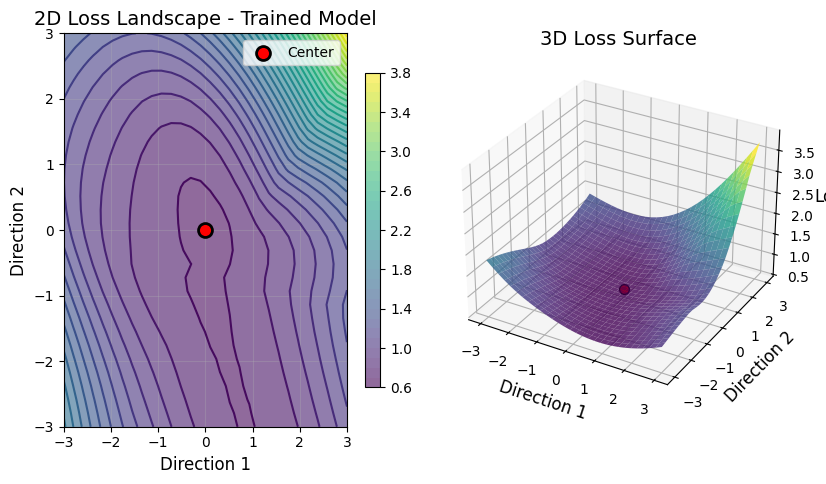

Loss at center (trained model): 0.6754
Test accuracy: 57.76%


In [32]:
# Create random direction slicer
random_slicer = RandomDirectionSlicer(final_wrapper)

# Perform 2D random direction slicing around the final trained model
random_slice_data = random_slicer.slice(
    center_point=None,  # Use current model parameters
    n_samples=SLICING_STEPS,
    x_range=(-PARAM_RANGE, PARAM_RANGE),
    y_range=(-PARAM_RANGE, PARAM_RANGE),
    normalize_directions=True,
    ensure_orthogonal=True
)

# Visualize the 2D loss landscape
fig = plot_slices(
    slice_data=random_slice_data,
    title="2D Loss Landscape - Trained Model",
)
plt.show()

print(f"Loss at center (trained model): {random_slice_data['center_loss']:.4f}")
print(f"Test accuracy: {test_accuracies[-1]:.2f}%")

## 5. Comparing Initial vs. Trained Loss Landscapes

Let's compare the loss landscapes of the initial (untrained) and final (trained) models to see how training affects the surface.

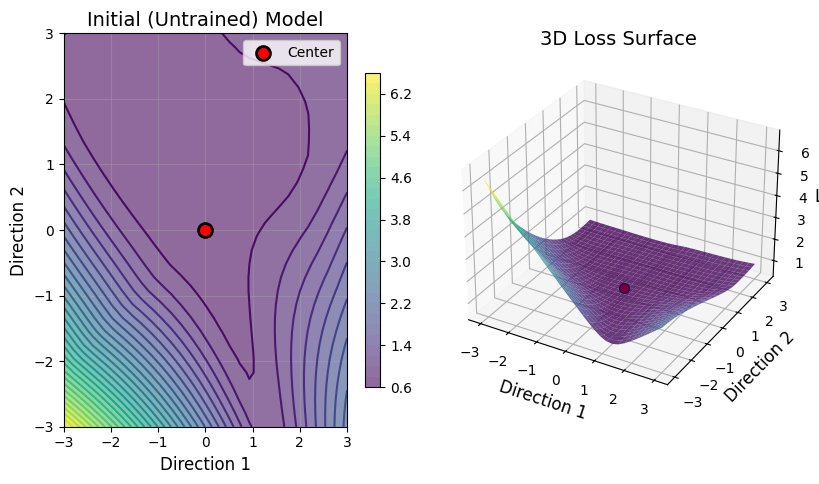

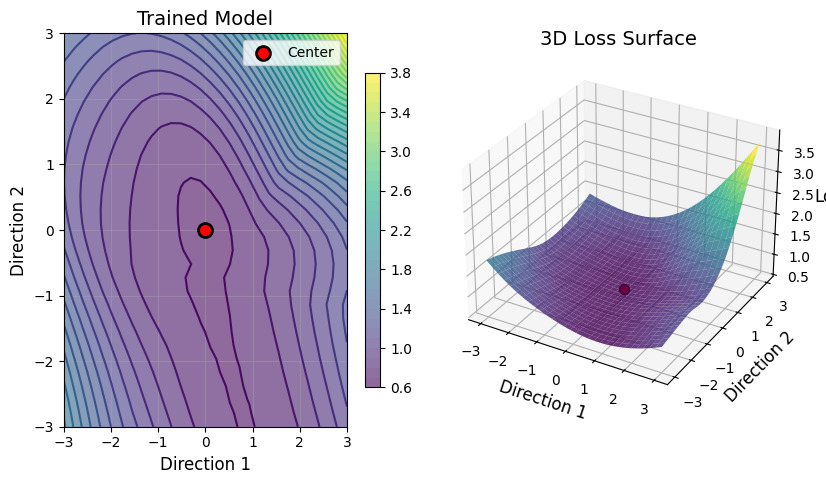

Initial model loss: 0.7071
Trained model loss: 0.6754
Improvement: 0.0317


In [33]:
# Slice around the initial (untrained) model
initial_slicer = RandomDirectionSlicer(initial_wrapper)
initial_slice_data = initial_slicer.slice(
    center_point=None,
    n_samples=SLICING_STEPS,
    x_range=(-PARAM_RANGE, PARAM_RANGE),
    y_range=(-PARAM_RANGE, PARAM_RANGE),
    normalize_directions=True,
    ensure_orthogonal=True
)

# Plot initial model landscape
fig1 = plot_slices(initial_slice_data, title="Initial (Untrained) Model")
plt.show()

# Plot trained model landscape
fig2 = plot_slices(random_slice_data, title="Trained Model")
plt.show()

print(f"Initial model loss: {initial_slice_data['center_loss']:.4f}")
print(f"Trained model loss: {random_slice_data['center_loss']:.4f}")
print(f"Improvement: {initial_slice_data['center_loss'] - random_slice_data['center_loss']:.4f}")

## 6. Axis-Parallel Slicing: Parameter Sensitivity Analysis

This analysis shows which parameters have the most influence on the loss function by varying each parameter independently.

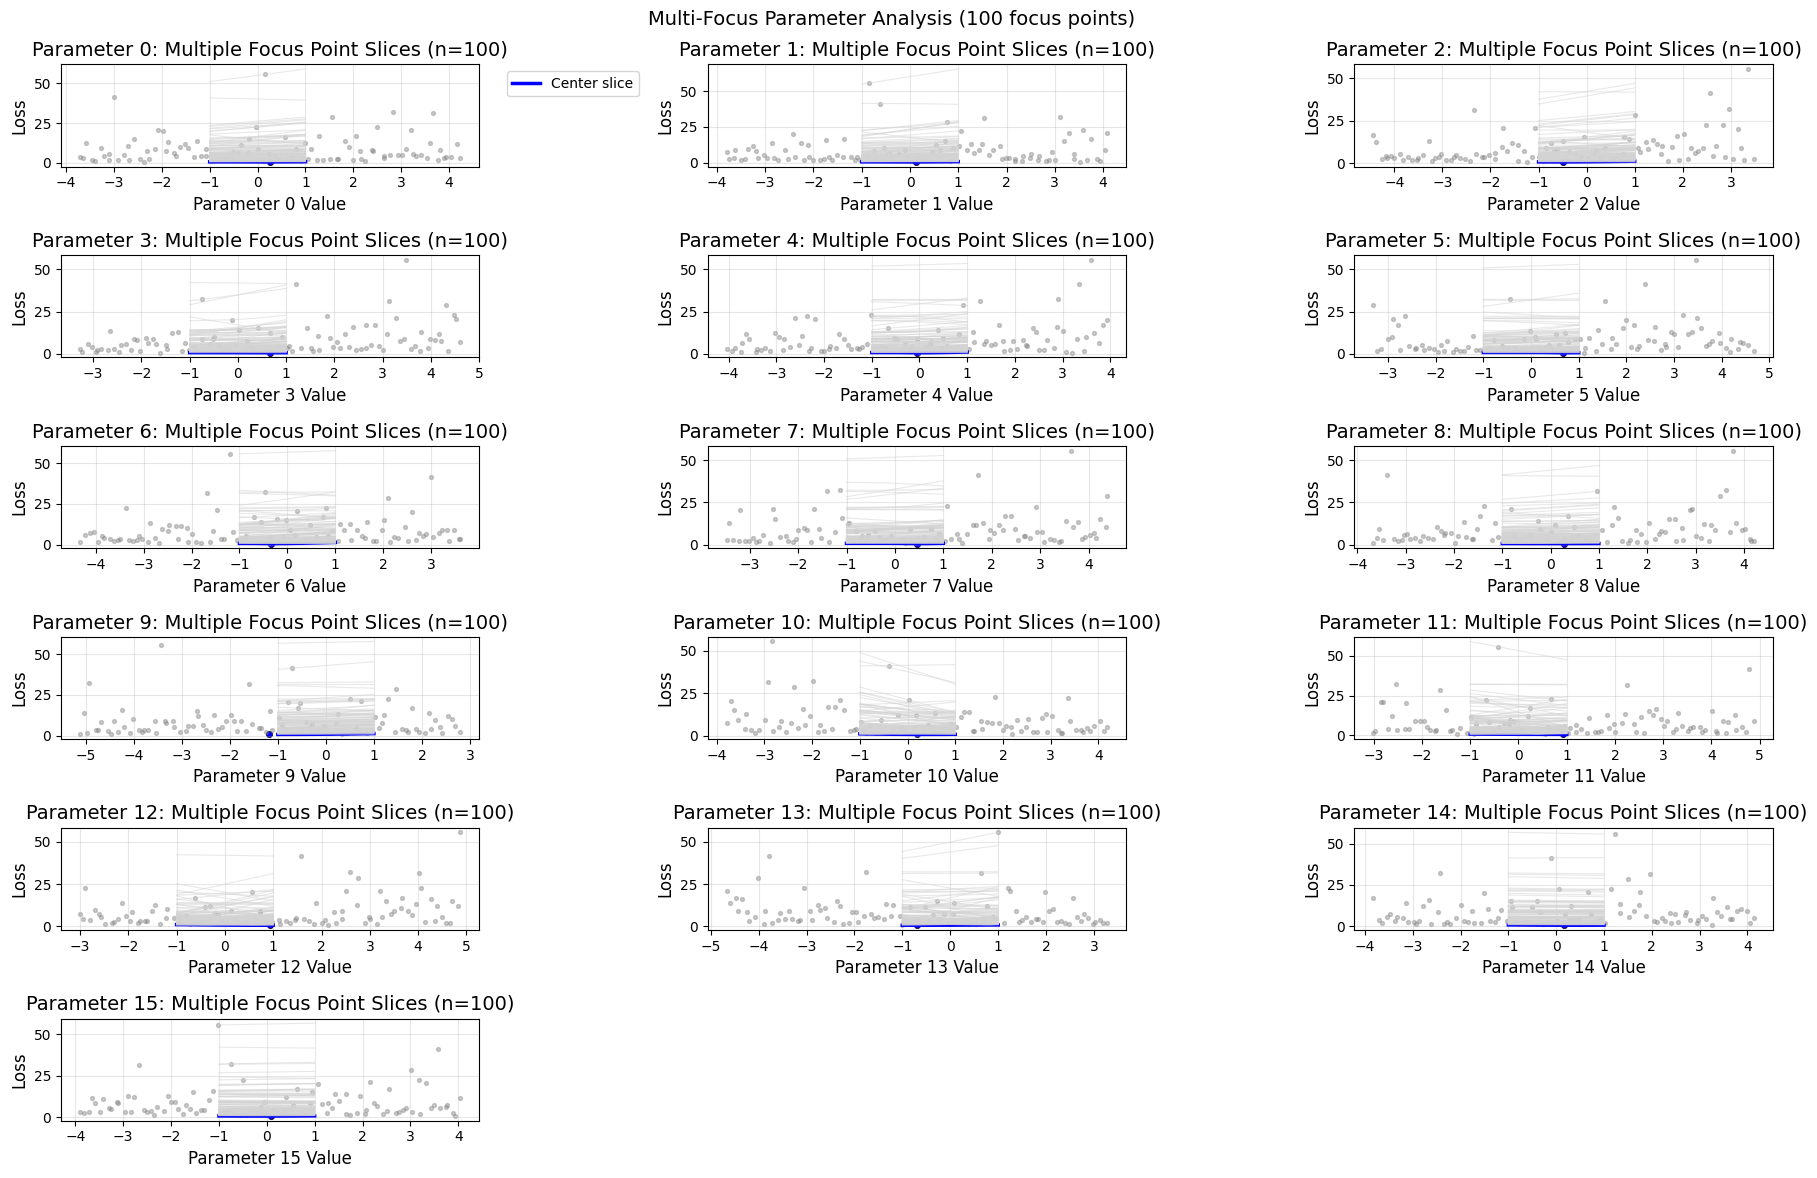

Analyzed 100 focus points
Total parameters: 16
Each subplot shows how varying one parameter affects the loss landscape


In [37]:
# Create axis-parallel slicer
axis_slicer = AxisParallelSlicer(final_wrapper)

# Perform axis-parallel slicing with multiple focus points
# With only 16 parameters, we can meaningfully visualize each one
axis_slice_data = axis_slicer.sample_focus_points_and_slice(
    center_point=None,
    n_points=100,
    sampling_method="lhs",
    radius=4,  
    bounds=(-1.0, 1.0),  
    n_samples_per_slice=SLICING_STEPS,
    bounds_mode="absolute",
    seed=42
)

# Visualize parameter sensitivity
fig = plot_slices(
    slice_data=axis_slice_data,
    title="Parameter Sensitivity Analysis - Tiny Network (16 parameters)",
)
plt.show()

print(f"Analyzed {len(axis_slice_data['focus_points'])} focus points")
print(f"Total parameters: {len(final_wrapper.get_parameters())}")
print("Each subplot shows how varying one parameter affects the loss landscape")

## 7. Linear Interpolation: Path Between Models

This shows the loss along the straight line path from the initial to the trained model, revealing the training trajectory.

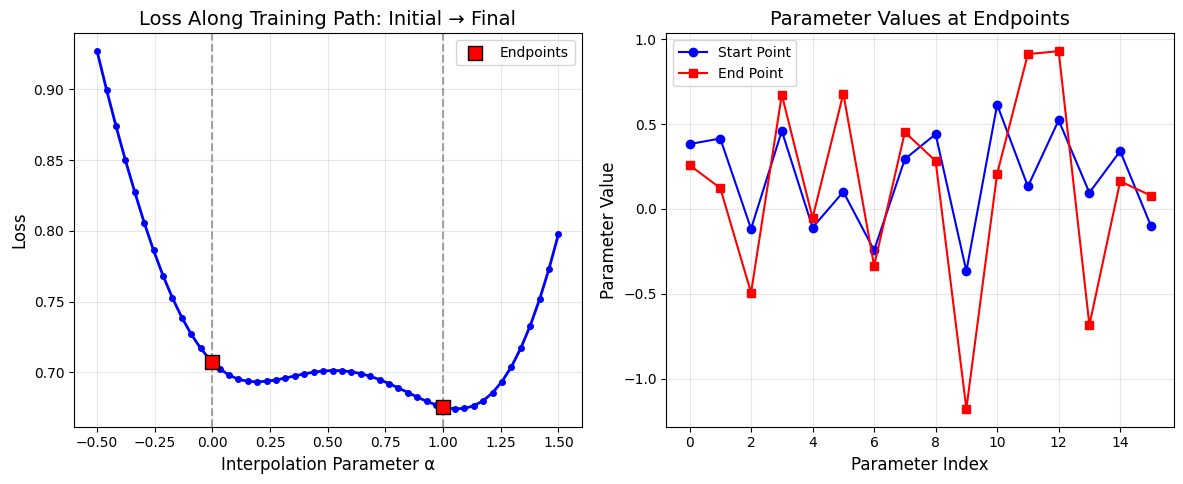

Loss barrier height: 0.2529


In [35]:
# Create linear interpolation slicer
linear_slicer = LinearInterpolationSlicer(final_wrapper)

# Get parameter vectors for initial and final models
initial_params = initial_wrapper.get_parameters()
final_params = final_wrapper.get_parameters()

# Slice between initial and final parameters
linear_slice_data = linear_slicer.slice(
    start_point=initial_params,
    end_point=final_params,
    n_samples=50
)

# Visualize the training path
fig = plot_slices(
    slice_data=linear_slice_data,
    title="Loss Along Training Path: Initial → Final",
)
plt.show()

print(f"Loss barrier height: {max([loss for _, loss in linear_slice_data['samples']]) - min([loss for _, loss in linear_slice_data['samples']]):.4f}")

## 8. Training Evolution Analysis

Let's analyze how the loss landscape evolves during training by comparing landscapes at different epochs.

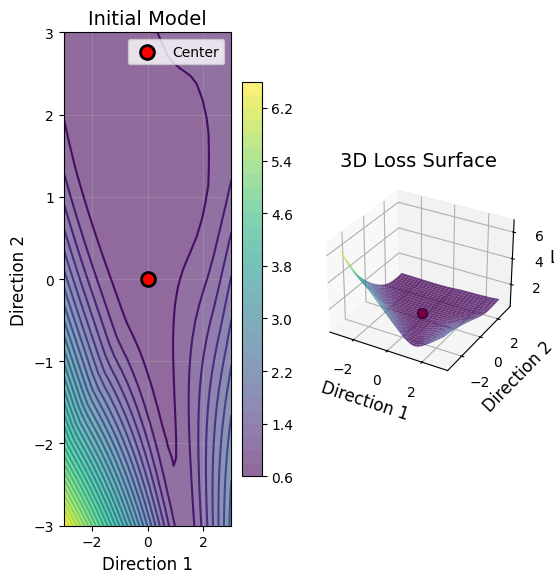

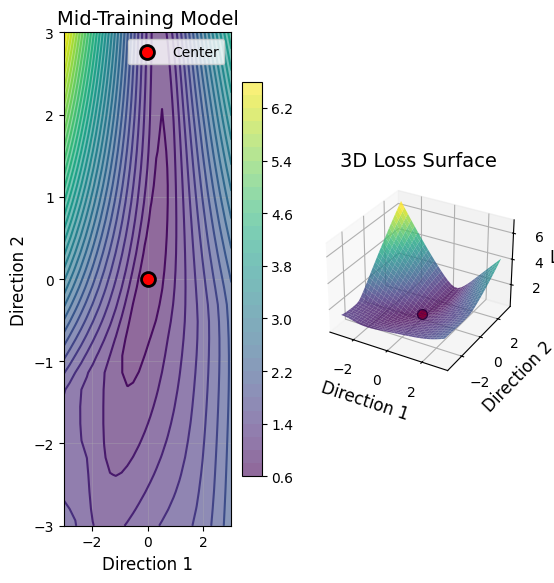

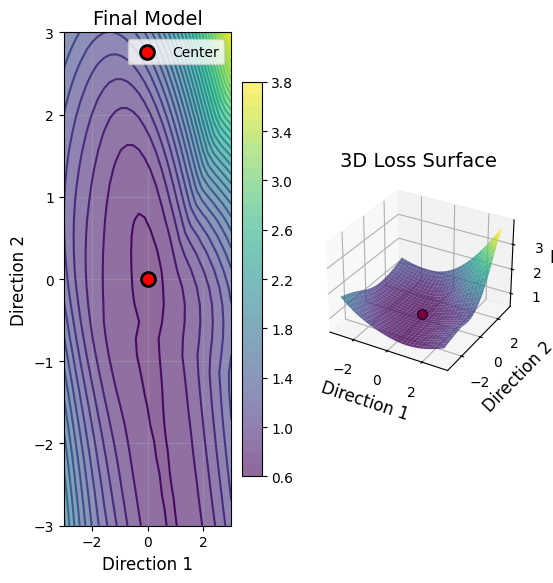

Training Evolution:
Initial loss: 0.7071
Mid-training loss: 0.6756
Final loss: 0.6754
Final test accuracy: 57.76%


In [36]:
# Create wrappers for different training stages
mid_training_wrapper = create_model_wrapper(model_snapshots[len(model_snapshots)//2], train_data_subset, test_data_subset)

# Slice around mid-training model
mid_slicer = RandomDirectionSlicer(mid_training_wrapper)
mid_slice_data = mid_slicer.slice(
    center_point=None,
    n_samples=SLICING_STEPS,
    x_range=(-PARAM_RANGE, PARAM_RANGE),
    y_range=(-PARAM_RANGE, PARAM_RANGE),
    normalize_directions=True,
    ensure_orthogonal=True
)

# Plot training evolution - Initial Model
fig1 = plot_slices(initial_slice_data, title="Initial Model", figsize=(8, 6))
plt.show()

# Plot training evolution - Mid-Training Model
fig2 = plot_slices(mid_slice_data, title="Mid-Training Model", figsize=(8, 6))
plt.show()

# Plot training evolution - Final Model
fig3 = plot_slices(random_slice_data, title="Final Model", figsize=(8, 6))
plt.show()

print("Training Evolution:")
print(f"Initial loss: {initial_slice_data['center_loss']:.4f}")
print(f"Mid-training loss: {mid_slice_data['center_loss']:.4f}")
print(f"Final loss: {random_slice_data['center_loss']:.4f}")
print(f"Final test accuracy: {test_accuracies[-1]:.2f}%")